In [53]:
!pip install nbconvert


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Bhautik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [54]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  si

C:\Users\Bhautik\AppData\Local\Temp\ipykernel_22260\3672318218.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data, x="label", palette="viridis")


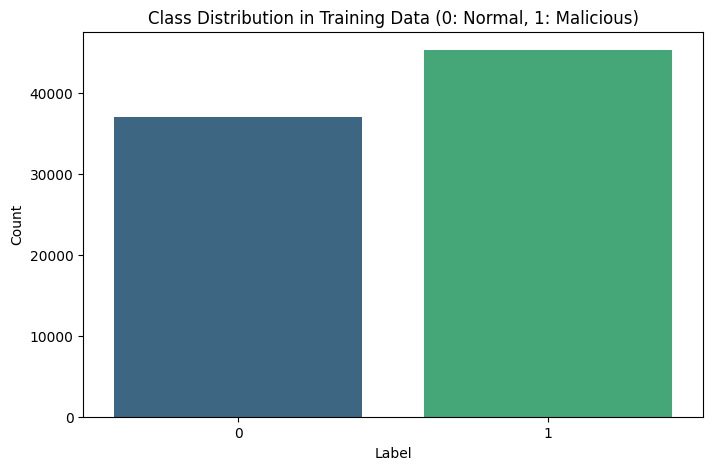

C:\Users\Bhautik\AppData\Local\Temp\ipykernel_22260\3672318218.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data, x="proto", order=train_data["proto"].value_counts().index[:10], palette="Set2")


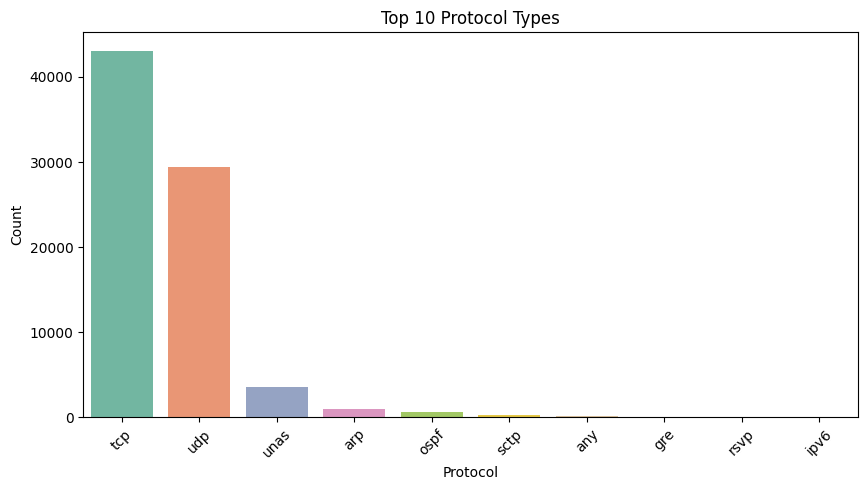

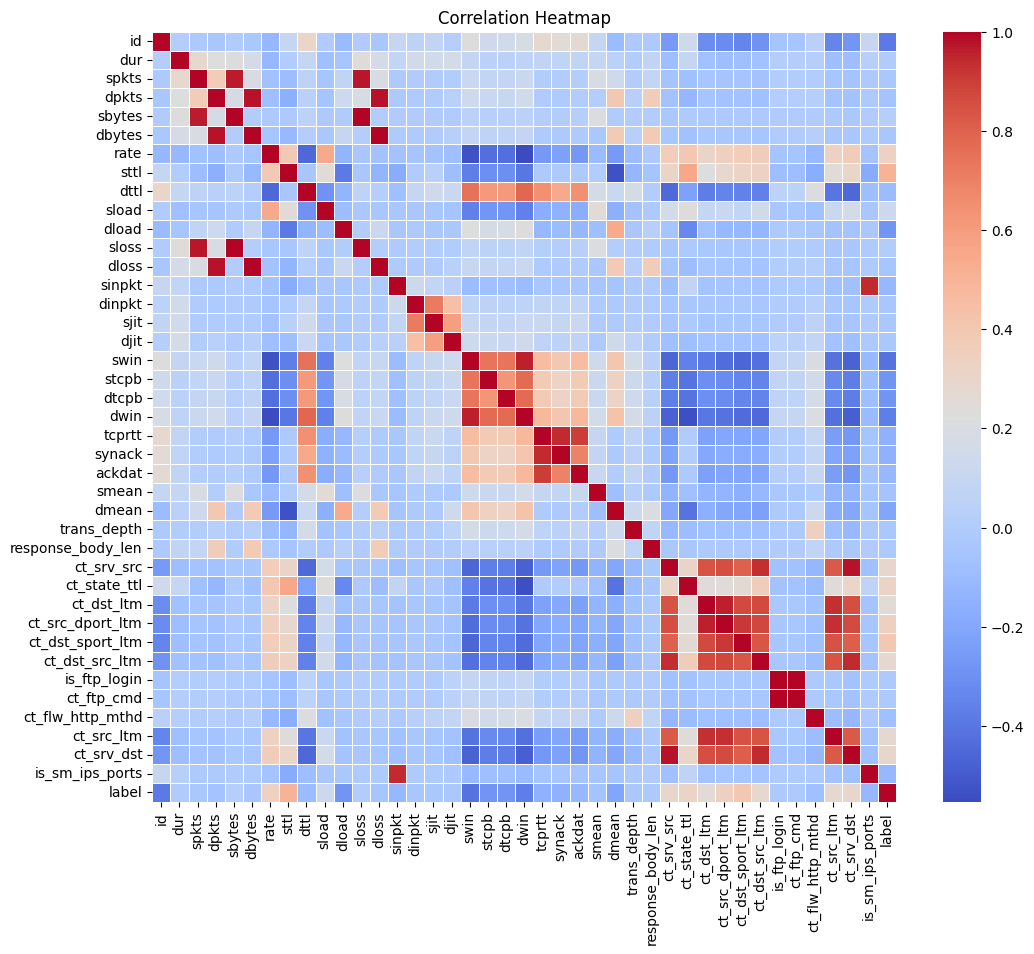

Count of label 0 entries: 37000
Count of label 1 entries: 45332


In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load training and testing datasets
train_path = "UNSW_NB15_training-set.csv"
test_path = "UNSW_NB15_testing-set.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Display basic info
print("Training Data Info:")
print(train_data.info())

print("\nSample Training Data:")
print(train_data.head())

# Check for missing values
print("\nMissing Values:")
print(train_data.isnull().sum())

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=train_data, x="label", palette="viridis")
plt.title("Class Distribution in Training Data (0: Normal, 1: Malicious)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Visualize protocol types
plt.figure(figsize=(10, 5))
sns.countplot(data=train_data, x="proto", order=train_data["proto"].value_counts().index[:10], palette="Set2")
plt.title("Top 10 Protocol Types")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Correlation heatmap
numeric_columns = train_data.select_dtypes(include=["float64", "int64"]).columns
correlation_matrix = train_data[numeric_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Count of label entries
label_counts = train_data["label"].value_counts()

print(f"Count of label 0 entries: {label_counts.get(0, 0)}")
print(f"Count of label 1 entries: {label_counts.get(1, 0)}")

In [56]:
# --- Cell 4: Common Data Preparation ---

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd

# Load training and testing datasets
train_path = "UNSW_NB15_training-set.csv"
test_path = "UNSW_NB15_testing-set.csv"

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

# Drop unnecessary columns from both datasets
train_df = train_data.drop(["id", "attack_cat"], axis=1, errors="ignore")
test_df = test_data.drop(["id", "attack_cat"], axis=1, errors="ignore")

# Drop sstl/sttl before model training pipeline
drop_cols = [c for c in ["sstl"] if c in train_df.columns]
if drop_cols:
    train_df = train_df.drop(columns=drop_cols, errors="ignore")
    test_df = test_df.drop(columns=drop_cols, errors="ignore")
    print(f"Dropped columns before training: {drop_cols}")
# ...existing code...

# Identify categorical columns
categorical_cols = train_df.select_dtypes(include=['object']).columns

# Use one-hot encoding to ensure columns are aligned
combined_data = pd.concat([train_df, test_df], axis=0)
encoded_data = pd.get_dummies(combined_data, columns=categorical_cols)

# Separate the combined data back into training and testing sets
X_train_df = encoded_data.iloc[:len(train_df)]
X_test_df = encoded_data.iloc[len(train_df):]

# Separate labels
y_train = X_train_df.pop('label')
y_test = X_test_df.pop('label')

# --- Feature Scaling ---
# Fit the scaler ONLY on the training data
scaler = MinMaxScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_df), columns=X_train_df.columns)

# Use the SAME scaler to transform the test data
X_test = pd.DataFrame(scaler.transform(X_test_df), columns=X_test_df.columns)

# Create folder for preprocessed data
import pickle
import os

preprocessed_folder = 'preprocessed_data'
os.makedirs(preprocessed_folder, exist_ok=True)

# Save preprocessed datasets
X_train.to_csv(f'{preprocessed_folder}/X_train.csv', index=False)
X_test.to_csv(f'{preprocessed_folder}/X_test.csv', index=False)
y_train.to_csv(f'{preprocessed_folder}/y_train.csv', index=False, header=['label'])
y_test.to_csv(f'{preprocessed_folder}/y_test.csv', index=False, header=['label'])

# Save scaler and feature columns for pipeline
with open(f'{preprocessed_folder}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(f'{preprocessed_folder}/feature_columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Data preprocessing complete.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\n✓ All preprocessed data saved to '{preprocessed_folder}/' folder:")
print(f"  - X_train.csv, X_test.csv")
print(f"  - y_train.csv, y_test.csv")
print(f"  - scaler.pkl, feature_columns.pkl")
print(len(X_train.columns))  # Output: 196 (approximately)

Data preprocessing complete.
X_train shape: (82332, 196)
X_test shape: (175341, 196)

✓ All preprocessed data saved to 'preprocessed_data/' folder:
  - X_train.csv, X_test.csv
  - y_train.csv, y_test.csv
  - scaler.pkl, feature_columns.pkl
196


In [57]:
# --- Optional: Load Preprocessed Data (Skip Cell 3 & 4 if using this) ---

import pandas as pd

# Load preprocessed datasets directly
preprocessed_folder = 'preprocessed_data'

X_train = pd.read_csv(f'{preprocessed_folder}/X_train.csv')
X_test = pd.read_csv(f'{preprocessed_folder}/X_test.csv')
y_train = pd.read_csv(f'{preprocessed_folder}/y_train.csv')['label']
y_test = pd.read_csv(f'{preprocessed_folder}/y_test.csv')['label']

print("✓ Preprocessed data loaded from files:")
print(f"  X_train shape: {X_train.shape}")
print(f"  X_test shape: {X_test.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  y_test shape: {y_test.shape}")

✓ Preprocessed data loaded from files:
  X_train shape: (82332, 196)
  X_test shape: (175341, 196)
  y_train shape: (82332,)
  y_test shape: (175341,)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Bhautik\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Model saved as random_forest_model.pkl
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.98      0.87     56000
           1       0.99      0.87      0.93    119341

    accuracy                           0.90    175341
   macro avg       0.88      0.92      0.90    175341
weighted avg       0.92      0.90      0.91    175341


Confusion Matrix:
[[ 54760   1240]
 [ 15442 103899]]


<Figure size 800x600 with 0 Axes>

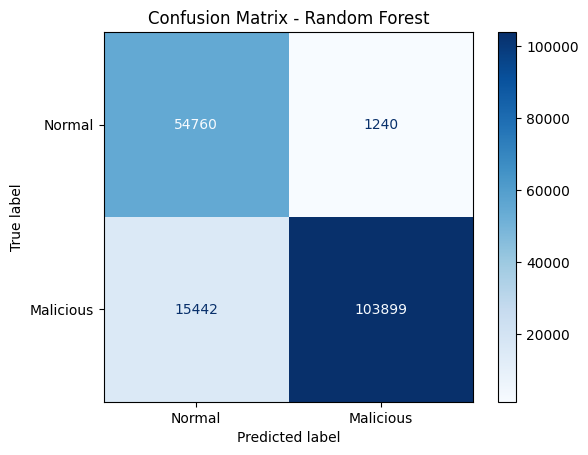


Accuracy: 0.9049


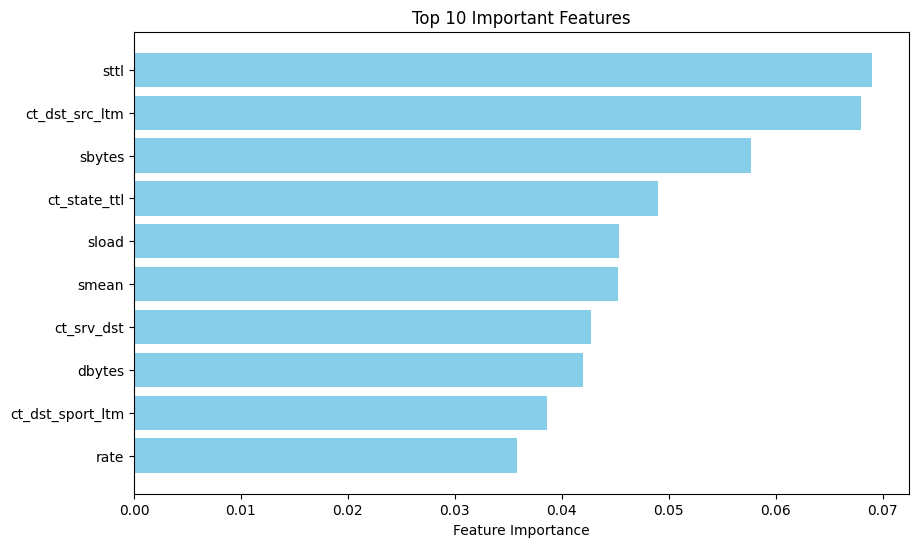

In [58]:
# --- Cell 5: Random Forest Classifier and SHAP ---

!pip install shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import shap
import matplotlib.pyplot as plt
import numpy as np
import pickle 

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,        # More trees = better (compute cost acceptable)
    max_depth=25,            # Prevent excessive depth
    min_samples_split=10,    # Require more samples to split
    min_samples_leaf=4,      # Prevent tiny leaves
    max_features='sqrt',     # Keep default (good for classification)
    n_jobs=-1,              # Use all CPU cores (MUCH faster training)
    random_state=42
)
rf_model.fit(X_train, y_train)

# Save the model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("Model saved as random_forest_model.pkl")


# Make predictions
y_pred = rf_model.predict(X_test)

# Classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Malicious"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")

# Visualize feature importance
feature_importance = rf_model.feature_importances_
features = X_train.columns
sorted_idx = np.argsort(feature_importance)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(features[sorted_idx], feature_importance[sorted_idx], color="skyblue")
plt.xlabel("Feature Importance")
plt.title("Top 10 Important Features")
plt.show()

# # --- SHAP Analysis ---
# # Using a smaller sample for faster computation
# X_test_sample = X_test.sample(n=1000, random_state=42)

# explainer = shap.TreeExplainer(rf_model)

# # FIX: Use explainer(X) instead of explainer.shap_values(X)
# # This returns a shap.Explanation object which automatically handles data alignment
# shap_explanation = explainer(X_test_sample)

# # Check shape to handle binary classification (Samples, Features, Classes)
# # We want the values for Class 1 (the positive class)
# if len(shap_explanation.shape) == 3:
#     shap_values = shap_explanation[:, :, 1]
# else:
#     shap_values = shap_explanation

# print("\nSHAP Summary Plot:")
# # Pass the Explanation object directly. It contains both values and data.
# shap.summary_plot(shap_values, X_test_sample)

# print("\nSHAP Waterfall Plot (for a single prediction):")
# # Pass the Explanation object for the first sample (index 0)
# shap.waterfall_plot(shap_values[0])

In [ ]:
# Conclusion: For UNSW-NB15 network intrusion detection, Random Forest outperforms XGBoost. This can happen when:

# Dataset has high-dimensional sparse features (from one-hot encoding)
# Class imbalance (Normal: 56K, Malicious: 119K)
# Random Forest's ensemble voting works better for this specific data distribution

In [59]:
import joblib

# Load the scaler
scaler = joblib.load('scaler.pkl')

# Print exactly what the model expects to see
print("First 10 columns:", list(scaler.feature_names_in_[:10]))
print("\nLast 10 columns:", list(scaler.feature_names_in_[-10:]))

First 10 columns: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload']

Last 10 columns: ['state_CLO', 'state_CON', 'state_ECO', 'state_FIN', 'state_INT', 'state_PAR', 'state_REQ', 'state_RST', 'state_URN', 'state_no']
